# Six-Way Imputation Comparison on Future Unseen Examples

Six variants: mean, median, nearest-neighbor (k=5, distance-weighted) each on original units and on standardized units.

Standardization (z-score): `z = (x - mean) / scale` with fixed `mean_` / `scale_` learned once from `kc_house_data.csv`. Distance for neighbor search is computed in `z` space, then results are converted back with `x = z * scale + mean`.

Test: `future_unseen_examples.csv` (100 rows, no missing) with 15% masked per column, seed 42. Scores are root mean squared error and mean absolute error at masked positions only.

In [24]:
import pathlib

import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

REQUEST_COLS = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "sqft_above", "sqft_basement"]
DATA_DIR = pathlib.Path("../src/data") if pathlib.Path("../src/data").exists() else pathlib.Path("src/data")

ref = pd.read_csv(DATA_DIR / "kc_house_data.csv", usecols=REQUEST_COLS)
future = pd.read_csv(DATA_DIR / "future_unseen_examples.csv")
print(f"Reference: {ref.shape}, future: {future.shape}")

rng = np.random.default_rng(42)
mask = pd.DataFrame(False, index=future.index, columns=REQUEST_COLS)
for col in REQUEST_COLS:
    idx = rng.choice(future.index, size=int(len(future) * 0.15), replace=False)
    mask.loc[idx, col] = True
masked = future.copy()
masked[REQUEST_COLS] = future[REQUEST_COLS].mask(mask)
print(f"Masked cells: {int(mask.sum().sum())}")
masked.head()

Reference: (21613, 7), future: (100, 18)
Masked cells: 105


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,4.0,1.00,1680.0,5043.0,1.5,0,0,4,6,1680.0,0.0,1911,0,98118,47.5354,-122.273,1560,5765
1,3.0,2.50,2220.0,6380.0,1.5,0,0,4,8,1660.0,560.0,1931,0,98115,47.6974,-122.313,950,6380
2,3.0,2.25,1630.0,10962.0,1.0,0,0,4,8,1100.0,530.0,1977,0,98030,47.3801,-122.166,1830,8470
3,5.0,2.50,1710.0,9720.0,NaN,0,0,4,8,NaN,0.0,1974,0,98005,47.5903,-122.157,2270,9672
4,2.0,1.00,850.0,6370.0,1.0,0,0,3,6,850.0,0.0,1951,0,98126,47.5198,-122.373,850,5170


In [25]:
# Fit six imputers: 3 methods x 2 spaces. Scaled variants fit in z-space.
scaler = StandardScaler().fit(ref)
ref_scaled = scaler.transform(ref)
masked_scaled = scaler.transform(masked[REQUEST_COLS])

models = {
    "mean_raw": SimpleImputer(strategy="mean").fit(ref),
    "median_raw": SimpleImputer(strategy="median").fit(ref),
    "knn_raw": KNNImputer(n_neighbors=5, weights="distance").fit(ref),
    "mean_scaled": SimpleImputer(strategy="mean").fit(ref_scaled),
    "median_scaled": SimpleImputer(strategy="median").fit(ref_scaled),
    "knn_scaled": KNNImputer(n_neighbors=5, weights="distance").fit(ref_scaled),
}

filled = {}
for name, imp in models.items():
    if "scaled" in name:
        back = scaler.inverse_transform(imp.transform(masked_scaled))
        filled[name] = pd.DataFrame(back, columns=REQUEST_COLS)
    else:
        filled[name] = pd.DataFrame(imp.transform(masked[REQUEST_COLS]), columns=REQUEST_COLS)
print(f"Remaining NaN per variant: { {k: int(v.isna().sum().sum()) for k, v in filled.items()} }")

# Per-feature RMSE and MAE at masked positions
rmse_rows = []
mae_rows = []
for col in REQUEST_COLS:
    m = mask[col]
    rmse_row = {"feature": col}
    mae_row = {"feature": col}
    for name in models:
        rmse_row[name] = float(np.sqrt(mean_squared_error(future.loc[m, col], filled[name].loc[m, col])))
        mae_row[name] = float(mean_absolute_error(future.loc[m, col], filled[name].loc[m, col]))
    rmse_rows.append(rmse_row)
    mae_rows.append(mae_row)
rmse_df = pd.DataFrame(rmse_rows).round(3)
mae_df = pd.DataFrame(mae_rows).round(3)
print("RMSE table:")
rmse_df

Remaining NaN per variant: {'mean_raw': 0, 'median_raw': 0, 'knn_raw': 0, 'mean_scaled': 0, 'median_scaled': 0, 'knn_scaled': 0}
RMSE table:


,feature,mean_raw,median_raw,knn_raw,mean_scaled,median_scaled,knn_scaled
0,bedrooms,0.626,0.775,0.213,0.626,0.775,0.119
1,bathrooms,0.671,0.668,0.058,0.671,0.668,0.027
2,sqft_living,833.492,852.780,46.992,833.492,852.780,44.922
3,sqft_lot,11469.008,11565.061,10116.588,11469.008,11565.061,10175.494
4,floors,0.486,0.483,0.000,0.486,0.483,0.000
5,sqft_above,713.596,797.187,8.262,713.596,797.187,4.688
6,sqft_basement,369.543,460.130,55.255,369.543,460.130,49.610


In [26]:
print("MAE table:")
mae_df

# Overall averages plus winner per feature (lowest RMSE)
avg = pd.DataFrame(
    {
        "variant": list(models.keys()),
        "avg_RMSE": [float(rmse_df[c].mean()) for c in models],
        "avg_MAE": [float(mae_df[c].mean()) for c in models],
    }
).round(3)
print("Overall averages (unweighted — dominated by sqft_lot):")
print(avg.to_string(index=False))
winners = rmse_df.set_index("feature").idxmin(axis=1).rename("best_RMSE")
print("\nWinner per feature:")
print(winners.to_string())

MAE table:
Overall averages (unweighted — dominated by sqft_lot):
      variant  avg_RMSE  avg_MAE
     mean_raw  1912.489 1585.774
   median_raw  1953.869 1263.836
      knn_raw  1461.053  588.995
  mean_scaled  1912.489 1585.774
median_scaled  1953.869 1263.836
   knn_scaled  1467.837  629.891

Winner per feature:
feature
bedrooms         knn_scaled
bathrooms        knn_scaled
sqft_living      knn_scaled
sqft_lot            knn_raw
floors              knn_raw
sqft_above       knn_scaled
sqft_basement    knn_scaled


In [27]:
# Long-format table: one row per masked cell.
# Columns: row_id | missing_attribute | actual | 6 imputed values
long_rows = []
for col in REQUEST_COLS:
    for idx in future.index[mask[col]]:
        entry = {"row_id": int(idx), "missing_attribute": col, "actual": float(future.loc[idx, col])}
        for name in models:
            entry[name] = float(filled[name].loc[idx, col])
        long_rows.append(entry)
long_df = pd.DataFrame(long_rows).sort_values(["missing_attribute", "row_id"]).reset_index(drop=True)
print(f"Masked cells: {len(long_df)}")
long_df.head(20)

Masked cells: 105


,row_id,missing_attribute,actual,mean_raw,median_raw,knn_raw,mean_scaled,median_scaled,knn_scaled
0,5,bathrooms,2.75,2.114757,2.25,2.75,2.114757,2.25,2.750000
1,8,bathrooms,1.75,2.114757,2.25,1.75,2.114757,2.25,1.750000
2,16,bathrooms,2.50,2.114757,2.25,2.50,2.114757,2.25,2.500000
3,19,bathrooms,1.00,2.114757,2.25,1.00,2.114757,2.25,1.000000
4,26,bathrooms,2.50,2.114757,2.25,2.70,2.114757,2.25,2.500000
5,35,bathrooms,2.50,2.114757,2.25,2.60,2.114757,2.25,2.500000
6,38,bathrooms,1.00,2.114757,2.25,1.00,2.114757,2.25,1.106222
7,39,bathrooms,1.00,2.114757,2.25,1.00,2.114757,2.25,1.000000
8,49,bathrooms,2.50,2.114757,2.25,2.50,2.114757,2.25,2.500000
9,60,bathrooms,2.50,2.114757,2.25,2.50,2.114757,2.25,2.500002


## Chart 0 — Masked-cells visual: who wins each individual cell?

The long table above has one row per masked cell. This chart counts, per missing attribute, which variant lands closest to the actual value. Taller segment = more cells won. Same paired palette and order as Charts 1–2.

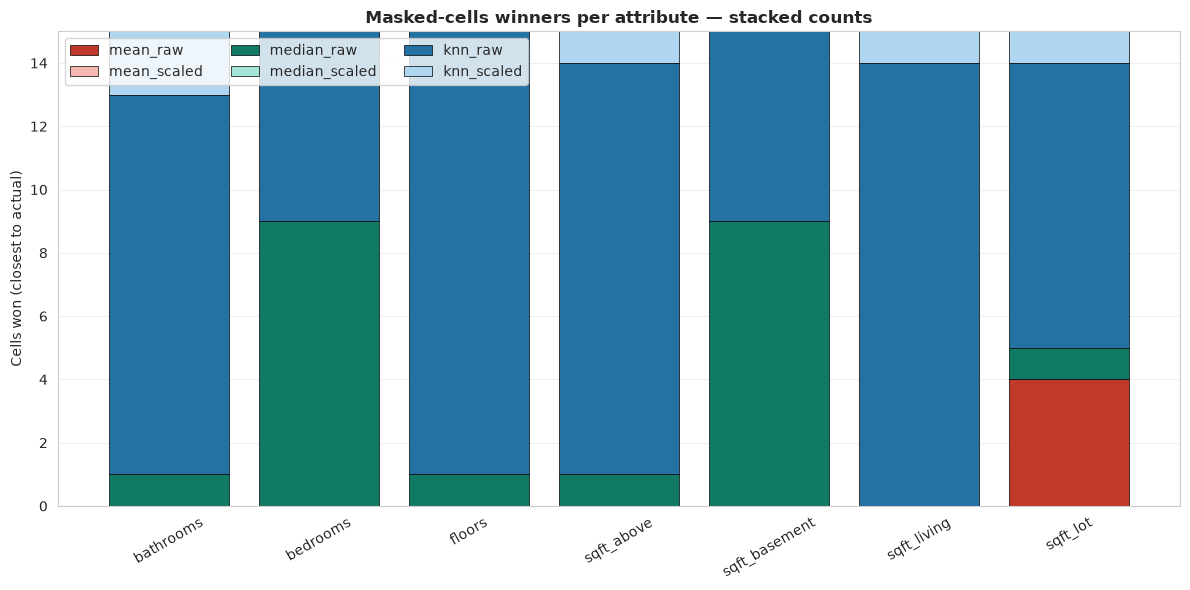

winner             mean_raw  median_raw  knn_raw  mean_scaled  median_scaled  knn_scaled
missing_attribute                                                                       
bathrooms                 0           1       12            0              0           2
bedrooms                  0           9        6            0              0           0
floors                    0           1       14            0              0           0
sqft_above                0           1       13            0              0           1
sqft_basement             0           9        6            0              0           0
sqft_living               0           0       14            0              0           1
sqft_lot                  4           1        9            0              0           1


In [28]:
# Stacked bars: per missing attribute, count of cells where each variant is closest to actual.
# Order and palette match Charts 1-2: raw set first, then scaled set.
ordered_variants = ["mean_raw", "median_raw", "knn_raw", "mean_scaled", "median_scaled", "knn_scaled"]
paired_colors = {
    "mean_raw": "#C0392B",
    "mean_scaled": "#F5B7B1",
    "median_raw": "#117A65",
    "median_scaled": "#A3E4D7",
    "knn_raw": "#2471A3",
    "knn_scaled": "#AED6F1",
}

err = long_df.copy()
for var in ordered_variants:
    err[var] = (long_df[var] - long_df["actual"]).abs()
err["winner"] = err[ordered_variants].idxmin(axis=1)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
attrs = list(long_df["missing_attribute"].unique())
counts = pd.crosstab(err["missing_attribute"], err["winner"]).reindex(index=attrs, columns=ordered_variants, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = [0] * len(attrs)
for var in ordered_variants:
    vals = counts[var].tolist()
    ax.bar(attrs, vals, bottom=bottom, label=var, color=paired_colors[var], edgecolor="black", linewidth=0.5)
    bottom = [b + v for b, v in zip(bottom, vals, strict=True)]
ax.set_ylabel("Cells won (closest to actual)")
ax.set_title("Masked-cells winners per attribute — stacked counts", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
handles, labels = ax.get_legend_handles_labels()
legend_order = [0, 3, 1, 4, 2, 5]
ax.legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], ncols=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print(counts.to_string())

## Chart 1 — Absolute RMSE on log scale (grouped bars)

Preserves absolute magnitudes. Log y-axis keeps features from 0.03 to 11,000 visible together. Each feature shows all six variants side by side.

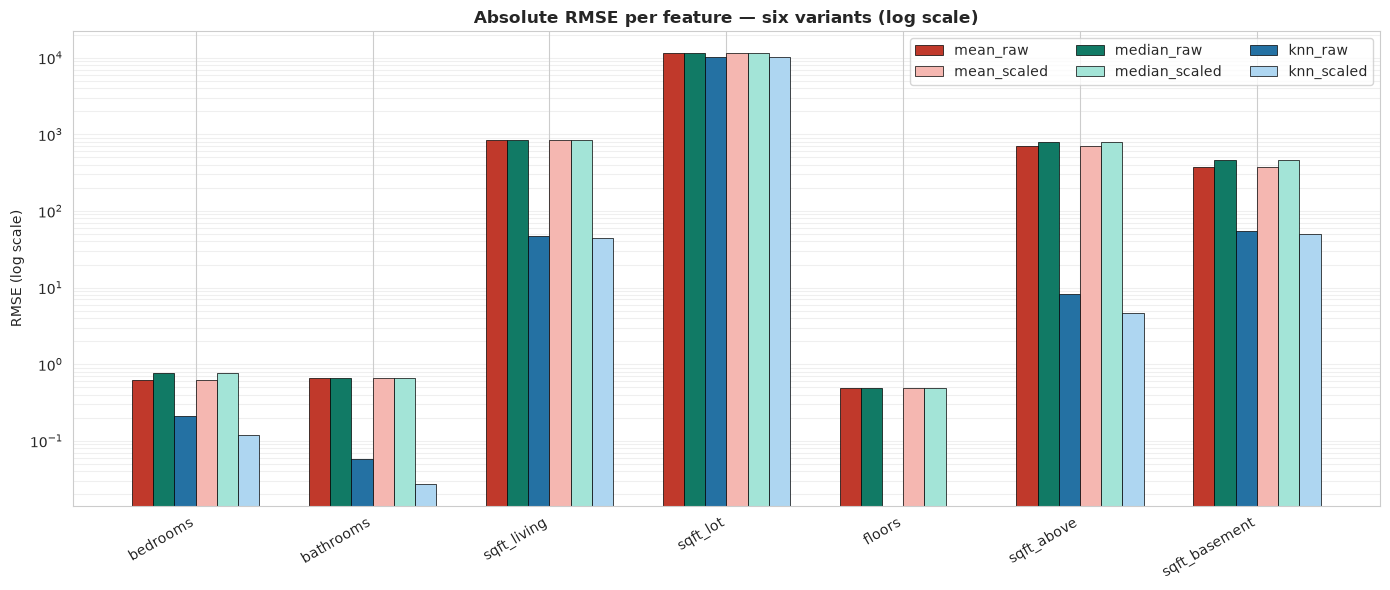

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
# Order: raw set first (mean, median, knn), then scaled set (mean, median, knn).
# Each method keeps its base hue; raw = dark, scaled = light.
# Same order and colors are reused in Chart 2.
ordered_variants = ["mean_raw", "median_raw", "knn_raw", "mean_scaled", "median_scaled", "knn_scaled"]
paired_colors = {
    "mean_raw": "#C0392B",
    "mean_scaled": "#F5B7B1",
    "median_raw": "#117A65",
    "median_scaled": "#A3E4D7",
    "knn_raw": "#2471A3",
    "knn_scaled": "#AED6F1",
}
x = np.arange(len(REQUEST_COLS))
width = 0.12

fig, ax = plt.subplots(figsize=(14, 6))
for i, var in enumerate(ordered_variants):
    ax.bar(x + (i - 2.5) * width, rmse_df[var], width, label=var, color=paired_colors[var], edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(REQUEST_COLS, rotation=30, ha="right")
ax.set_ylabel("RMSE (log scale)")
ax.set_title("Absolute RMSE per feature — six variants (log scale)", fontweight="bold")
# Legend fills down columns, so interleave handles to get top row = raw, bottom row = scaled.
handles, labels = ax.get_legend_handles_labels()
legend_order = [0, 3, 1, 4, 2, 5]
ax.legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], ncols=3)
ax.grid(axis="y", alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Chart 2 — Scale-free comparison: RMSE divided by feature spread

Raw RMSE cannot be compared across features because lot size is measured in tens of thousands and bathroom count below one. Dividing each RMSE by the reference standard deviation puts every feature on the same footing: a value of 1.0 means error as large as the natural spread. Lower is better.

Average scale-free RMSE (lower is better):
      variant  avg_norm_RMSE
   knn_scaled         0.0822
      knn_raw         0.1049
  mean_scaled         0.7608
     mean_raw         0.7608
   median_raw         0.8293
median_scaled         0.8293


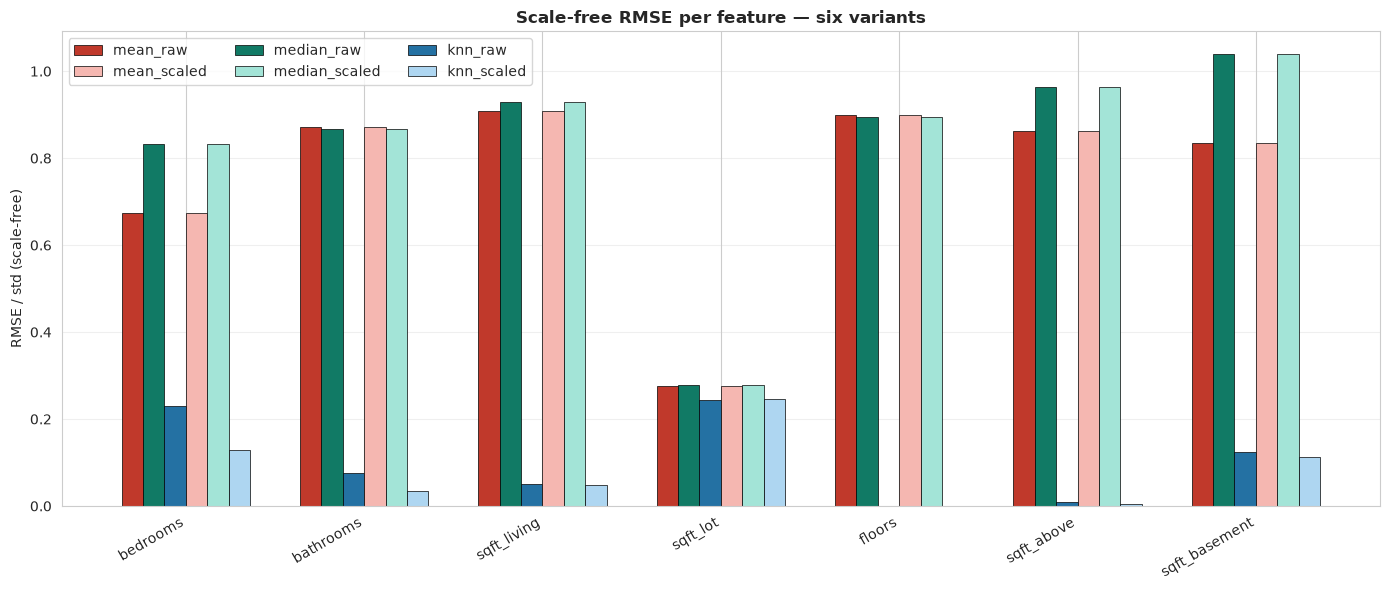

,feature,mean_raw,median_raw,knn_raw,mean_scaled,median_scaled,knn_scaled
0,bedrooms,0.6731,0.8333,0.2290,0.6731,0.8333,0.1280
1,bathrooms,0.8713,0.8674,0.0753,0.8713,0.8674,0.0351
2,sqft_living,0.9075,0.9285,0.0512,0.9075,0.9285,0.0489
3,sqft_lot,0.2769,0.2792,0.2442,0.2769,0.2792,0.2457
4,floors,0.9000,0.8945,0.0000,0.9000,0.8945,0.0000
5,sqft_above,0.8618,0.9627,0.0100,0.8618,0.9627,0.0057
6,sqft_basement,0.8350,1.0397,0.1249,0.8350,1.0397,0.1121


In [30]:
std = pd.Series(scaler.scale_, index=REQUEST_COLS)
norm_df = rmse_df.copy()
for var in ordered_variants:
    norm_df[var] = rmse_df[var] / std[REQUEST_COLS].values
norm_avg = (
    pd.DataFrame(
        {
            "variant": ordered_variants,
            "avg_norm_RMSE": [float(norm_df[v].mean()) for v in ordered_variants],
        }
    )
    .sort_values("avg_norm_RMSE")
    .round(4)
)
print("Average scale-free RMSE (lower is better):")
print(norm_avg.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
for i, var in enumerate(ordered_variants):
    ax.bar(x + (i - 2.5) * width, norm_df[var], width, label=var, color=paired_colors[var], edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(REQUEST_COLS, rotation=30, ha="right")
ax.set_ylabel("RMSE / std (scale-free)")
ax.set_title("Scale-free RMSE per feature — six variants", fontweight="bold")
# Legend fills down columns, so interleave handles to get top row = raw, bottom row = scaled.
handles, labels = ax.get_legend_handles_labels()
legend_order = [0, 3, 1, 4, 2, 5]
ax.legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], ncols=3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
norm_df.round(4)

## Table + Chart 3 — Price per example: what does each imputation mistake cost?

Each future row exists in `kc_house_data.csv`, so we know its true sale price. For every masked cell we predict the price with true features (baseline) and with each variant's imputed value, then measure absolute price error versus the true sale price. Table shows all 105 masked cells with price; chart shows mean price error per variant plus per-example spread.

In [ ]:
# Two separate tables: attribute table + price table.
# Attribute table: row_id | missing_attribute | actual_value | per variant: value + delta + err.
# Price table: row_id | missing_attribute | actual_price | pred_true_features | per variant: price + delta + err.
import json
import pickle

kc_full = pd.read_csv(DATA_DIR / "kc_house_data.csv")
common = [c for c in future.columns if c in kc_full.columns]
price_lookup = kc_full.drop_duplicates(subset=common).set_index(common)["price"]

with (DATA_DIR.parent / "model" / "model.pkl").open("rb") as f:
    price_model = pickle.load(f)  # noqa: S301 — trusted build artifact
with (DATA_DIR.parent / "model" / "model_features.json").open() as f:
    model_features = json.load(f)
demographics = pd.read_csv(DATA_DIR / "zipcode_demographics.csv", dtype={"zipcode": str})


def predict_row(row: pd.Series) -> float:
    frame = pd.DataFrame([row])
    # Zipcode may arrive as float (98118.0) — normalize to plain "98118" for the join.
    frame["zipcode"] = frame["zipcode"].apply(lambda z: str(int(z)))
    demo = frame[["zipcode"]].merge(demographics, how="left", on="zipcode")
    pf = pd.concat([frame[REQUEST_COLS].reset_index(drop=True), demo.drop(columns="zipcode").reset_index(drop=True)], axis=1)
    return float(price_model.predict(pf[model_features])[0])


attr_rows = []
price_rows = []
for _, cell in long_df.iterrows():
    rid = int(cell["row_id"])
    attr = cell["missing_attribute"]
    base_row = future.loc[rid]
    key = tuple(base_row[c] for c in common)
    true_price = float(price_lookup.loc[key]) if isinstance(key, tuple) else float(price_lookup.loc[key])
    base_pred = predict_row(base_row)
    actual_value = float(cell["actual"])
    attr_entry: dict[str, object] = {"row_id": rid, "missing_attribute": attr, "actual_value": actual_value}
    price_entry: dict[str, object] = {
        "row_id": rid,
        "missing_attribute": attr,
        "actual_price": true_price,
        "pred_true_features": round(base_pred, 0),
    }
    for var in ordered_variants:
        mod_row = base_row.copy()
        mod_row[attr] = cell[var]
        pred = predict_row(mod_row)
        imp_value = float(cell[var])
        attr_entry[var + "_value"] = round(imp_value, 3)
        attr_entry[var + "_value_delta"] = round(actual_value - imp_value, 3)
        attr_entry[var + "_value_err"] = round(abs(actual_value - imp_value), 3)
        price_entry[var + "_price"] = round(pred, 0)
        price_entry[var + "_price_delta"] = round(true_price - pred, 0)
        price_entry[var + "_price_err"] = round(abs(pred - true_price), 0)
    attr_rows.append(attr_entry)
    price_rows.append(price_entry)

attr_df = pd.DataFrame(attr_rows)
price_df = pd.DataFrame(price_rows)
print(f"Attribute table: {attr_df.shape} | Price table: {price_df.shape}")
print("\nAttribute table (first 10):")
print(attr_df.head(10).to_string(index=False))
print("\nPrice table (first 10):")
print(price_df.head(10).to_string(index=False))

Price table: (105, 41)
Columns: ['row_id', 'missing_attribute', 'actual_value', 'actual_price', 'pred_true_features', 'mean_raw_value', 'mean_raw_value_delta', 'mean_raw_value_err', 'mean_raw_price', 'mean_raw_price_delta', 'mean_raw_price_err', 'median_raw_value', 'median_raw_value_delta', 'median_raw_value_err', 'median_raw_price', 'median_raw_price_delta', 'median_raw_price_err', 'knn_raw_value', 'knn_raw_value_delta', 'knn_raw_value_err', 'knn_raw_price', 'knn_raw_price_delta', 'knn_raw_price_err', 'mean_scaled_value', 'mean_scaled_value_delta', 'mean_scaled_value_err', 'mean_scaled_price', 'mean_scaled_price_delta', 'mean_scaled_price_err', 'median_scaled_value', 'median_scaled_value_delta', 'median_scaled_value_err', 'median_scaled_price', 'median_scaled_price_delta', 'median_scaled_price_err', 'knn_scaled_value', 'knn_scaled_value_delta', 'knn_scaled_value_err', 'knn_scaled_price', 'knn_scaled_price_delta', 'knn_scaled_price_err']


,row_id,missing_attribute,actual_value,actual_price,pred_true_features,mean_raw_value,mean_raw_value_delta,mean_raw_value_err,mean_raw_price,mean_raw_price_delta,...,median_scaled_value_err,median_scaled_price,median_scaled_price_delta,median_scaled_price_err,knn_scaled_value,knn_scaled_value_delta,knn_scaled_value_err,knn_scaled_price,knn_scaled_price_delta,knn_scaled_price_err
0,5,bathrooms,2.75,619990.0,553798.0,2.115,0.635,0.635,544400.0,75590.0,...,0.50,544400.0,75590.0,75590.0,2.750,0.000,0.000,553798.0,66192.0,66192.0
1,8,bathrooms,1.75,1565000.0,990500.0,2.115,-0.365,0.365,950500.0,614500.0,...,0.50,1106980.0,458020.0,458020.0,1.750,0.000,0.000,990500.0,574500.0,574500.0
2,16,bathrooms,2.50,442250.0,426950.0,2.115,0.385,0.385,426950.0,15300.0,...,0.25,426950.0,15300.0,15300.0,2.500,-0.000,0.000,426950.0,15300.0,15300.0
3,19,bathrooms,1.00,255000.0,438000.0,2.115,-1.115,1.115,438000.0,-183000.0,...,1.25,449200.0,-194200.0,194200.0,1.000,0.000,0.000,438000.0,-183000.0,183000.0
4,26,bathrooms,2.50,700000.0,730800.0,2.115,0.385,0.385,647900.0,52100.0,...,0.25,718200.0,-18200.0,18200.0,2.500,0.000,0.000,730800.0,-30800.0,30800.0
5,35,bathrooms,2.50,324950.0,297900.0,2.115,0.385,0.385,297900.0,27050.0,...,0.25,297900.0,27050.0,27050.0,2.500,0.000,0.000,297900.0,27050.0,27050.0
6,38,bathrooms,1.00,105000.0,222590.0,2.115,-1.115,1.115,225190.0,-120190.0,...,1.25,256990.0,-151990.0,151990.0,1.106,-0.106,0.106,222590.0,-117590.0,117590.0
7,39,bathrooms,1.00,289000.0,297940.0,2.115,-1.115,1.115,338700.0,-49700.0,...,1.25,334400.0,-45400.0,45400.0,1.000,0.000,0.000,297940.0,-8940.0,8940.0
8,49,bathrooms,2.50,299950.0,288890.0,2.115,0.385,0.385,277690.0,22260.0,...,0.25,289690.0,10260.0,10260.0,2.500,0.000,0.000,288890.0,11060.0,11060.0
9,60,bathrooms,2.50,449950.0,486090.0,2.115,0.385,0.385,489890.0,-39940.0,...,0.25,489890.0,-39940.0,39940.0,2.500,-0.000,0.000,486090.0,-36140.0,36140.0


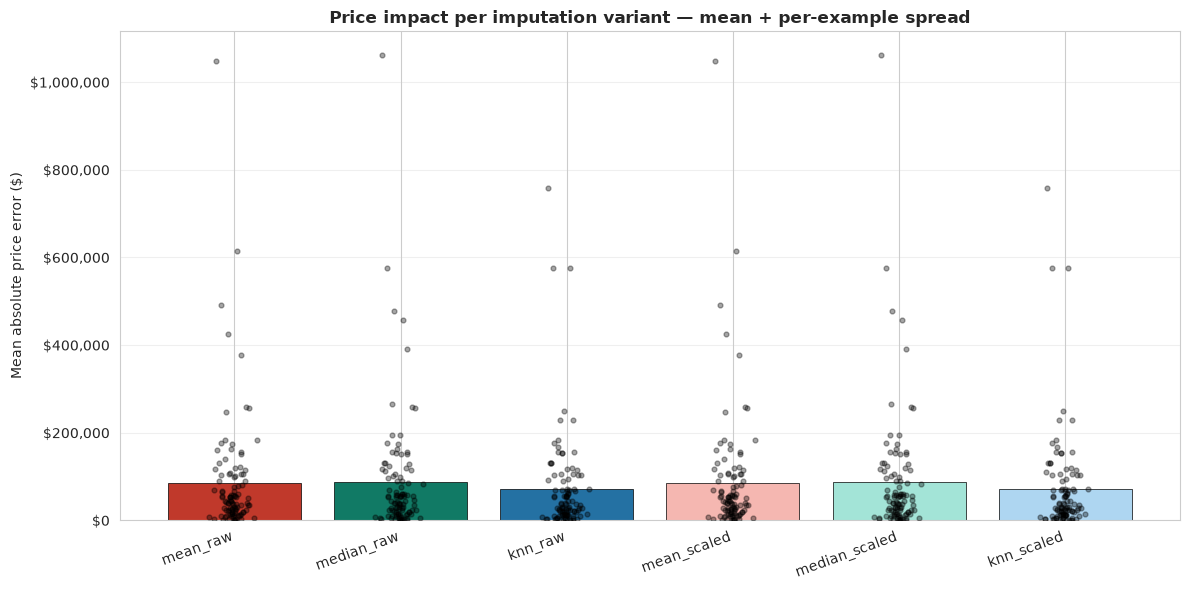

      variant  mean_price_err
      knn_raw         70557.0
   knn_scaled         71138.0
  mean_scaled         85745.0
     mean_raw         85745.0
   median_raw         87194.0
median_scaled         87194.0


In [32]:
# Chart 3 — mean absolute price error per variant (bars) with per-example dots.
# Same order and paired palette as Charts 0-2. Lower is better.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
err_cols = [var + "_price_err" for var in ordered_variants]
means = [float(price_df[c].mean()) for c in err_cols]

fig, ax = plt.subplots(figsize=(12, 6))
xpos = range(len(ordered_variants))
ax.bar(xpos, means, color=[paired_colors[v] for v in ordered_variants], edgecolor="black", linewidth=0.5, zorder=2)
# Per-example spread as jittered dots
for i, c in enumerate(err_cols):
    vals = price_df[c].to_numpy()
    jitter = np.random.default_rng(7).normal(0, 0.06, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=12, alpha=0.35, color="black", zorder=3)
ax.set_xticks(list(xpos))
ax.set_xticklabels(ordered_variants, rotation=20, ha="right")
ax.set_ylabel("Mean absolute price error ($)")
ax.set_title("Price impact per imputation variant — mean + per-example spread", fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({"variant": ordered_variants, "mean_price_err": [round(m, 0) for m in means]}).sort_values("mean_price_err")
print(summary.to_string(index=False))

## Tables + Chart 4 — Percent from actual per example

Two tables: attribute percent error and price percent error per masked cell, per variant. Percent = `100 * (calculated - actual) / actual` (NaN where actual is 0). Chart scatters actual (x) vs calculated (y) per example — diagonal means perfect.

In [33]:
# Percent-from-actual tables: attribute and price, per masked cell, per variant.
# pct = 100 * (calculated - actual) / actual; NaN where actual == 0.
attr_pct = pd.DataFrame({"row_id": price_df["row_id"], "missing_attribute": price_df["missing_attribute"], "actual_value": price_df["actual_value"]})
price_pct = pd.DataFrame({"row_id": price_df["row_id"], "missing_attribute": price_df["missing_attribute"], "actual_price": price_df["actual_price"]})
for var in ordered_variants:
    with np.errstate(divide="ignore", invalid="ignore"):
        attr_pct[var + "_pct"] = np.where(
            price_df["actual_value"] != 0,
            100 * (price_df[var + "_value"] - price_df["actual_value"]) / price_df["actual_value"],
            np.nan,
        )
        price_pct[var + "_pct"] = 100 * (price_df[var + "_price"] - price_df["actual_price"]) / price_df["actual_price"]
attr_pct = attr_pct.round(2)
price_pct = price_pct.round(2)
print(f"Attribute % table: {attr_pct.shape} | Price % table: {price_pct.shape}")
print("\nAttribute percent-from-actual (first 20):")
print(attr_pct.head(20).to_string(index=False))
print("\nPrice percent-from-actual (first 20):")
print(price_pct.head(20).to_string(index=False))

Attribute % table: (105, 9) | Price % table: (105, 9)

Attribute percent-from-actual (first 20):
 row_id missing_attribute  actual_value  mean_raw_pct  median_raw_pct  knn_raw_pct  mean_scaled_pct  median_scaled_pct  knn_scaled_pct
      5         bathrooms          2.75        -23.09          -18.18         0.00           -23.09             -18.18             0.0
      8         bathrooms          1.75         20.86           28.57         0.00            20.86              28.57             0.0
     16         bathrooms          2.50        -15.40          -10.00         0.00           -15.40             -10.00             0.0
     19         bathrooms          1.00        111.50          125.00         0.00           111.50             125.00             0.0
     26         bathrooms          2.50        -15.40          -10.00         8.00           -15.40             -10.00             0.0
     35         bathrooms          2.50        -15.40          -10.00         4.00           

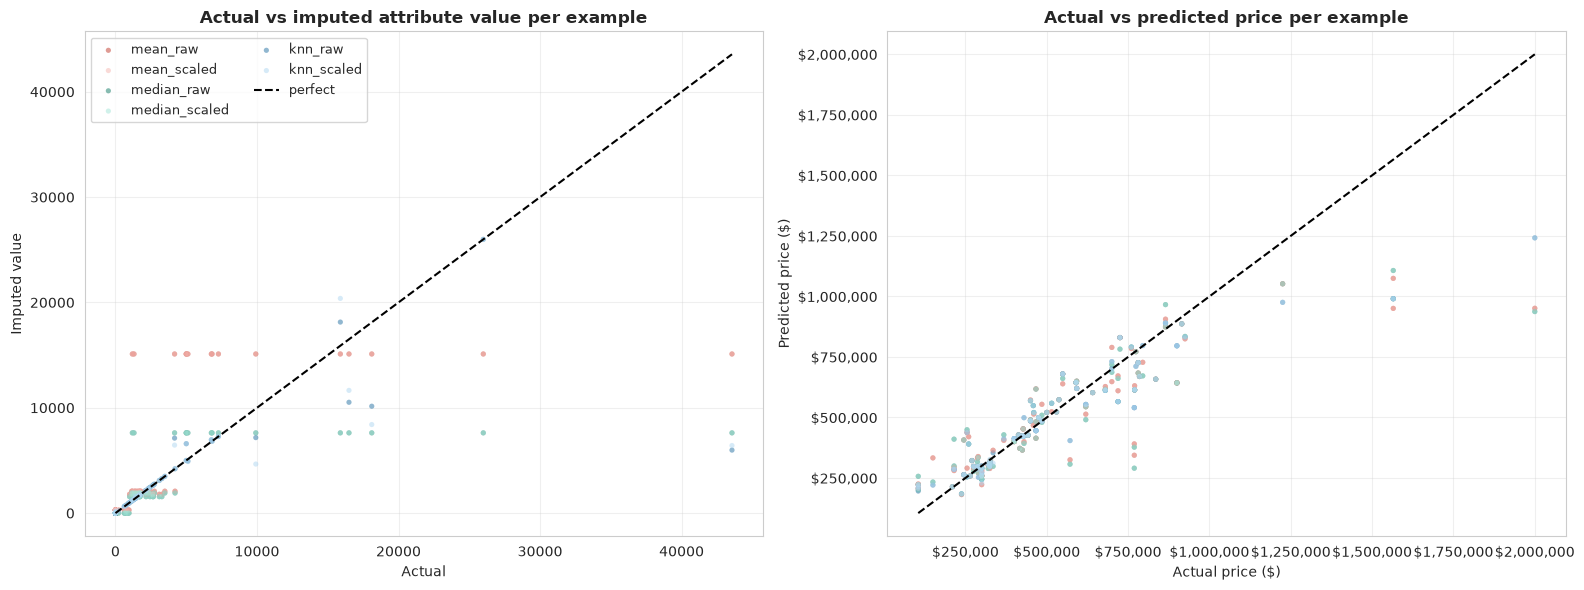

In [34]:
# Chart 4 — actual (x) vs calculated (y) per example, raw and scaled side by side.
# Left: attribute values. Right: prices. Diagonal = perfect. Same paired palette.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for var in ordered_variants:
    axes[0].scatter(price_df["actual_value"], price_df[var + "_value"], s=14, alpha=0.5, color=paired_colors[var], label=var, edgecolors="none")
    axes[1].scatter(price_df["actual_price"], price_df[var + "_price"], s=14, alpha=0.5, color=paired_colors[var], label=var, edgecolors="none")

for ax_i, xcol, ylab, title in [
    (0, "actual_value", "Imputed value", "Actual vs imputed attribute value per example"),
    (1, "actual_price", "Predicted price ($)", "Actual vs predicted price per example"),
]:
    lo = float(price_df["actual_price"].min()) if ax_i == 1 else float(price_df["actual_value"].min())
    hi = float(price_df["actual_price"].max()) if ax_i == 1 else float(price_df["actual_value"].max())
    axes[ax_i].plot([lo, hi], [lo, hi], "k--", lw=1.5, label="perfect")
    axes[ax_i].set_xlabel("Actual" if ax_i == 0 else "Actual price ($)")
    axes[ax_i].set_ylabel(ylab)
    axes[ax_i].set_title(title, fontweight="bold")
    axes[ax_i].grid(alpha=0.3)
    if ax_i == 1:
        axes[ax_i].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
        axes[ax_i].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))

handles, labels = axes[0].get_legend_handles_labels()
legend_order = [0, 3, 1, 4, 2, 5, 6]
axes[0].legend([handles[i] for i in legend_order], [labels[i] for i in legend_order], ncols=2, fontsize=9)
axes[1].legend().set_visible(False)
plt.tight_layout()
plt.show()